# 04 Modeling — tree-based whitespace scoring

Consumes `model_features_full.csv` (output of `03_data_prep.ipynb`, 186 anchors × 158 cols) and produces:
1. A trained tree model linking anchor features to a Y target (Sales / EBITDA, when client provides).
2. Feature importance + SHAP explanations for the business deck.
3. Scored whitespace candidates for the "where to open next" question.

**Sections**

| # | What | Status |
|---|---|---|
| 1 | Setup + load                            | runnable now |
| 2 | Feature catalog (★ edit `keep` here)    | runnable now |
| 3 | Feature engineering (derived ratios + X)| runnable now |
| 4 | Target loading (`y_targets.csv`)        | runnable after `03` Section 10 |
| 5 | XGBoost K-fold training                 | runnable now |
| 6 | Diagnostics (importance ranking + plots)| runnable now |
| 7 | Whitespace scoring                      | stub (also needs Section 2b in `03_data_prep`) |

## 1. Setup

In [94]:
# One-time install for the modeling stack. Comment out after first run.
# %pip install xgboost scikit-learn matplotlib shap --quiet

In [95]:
from pathlib import Path
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parents[0]
OUT_TABLES = ROOT / 'output' / 'tables'
OUT_MODELS = ROOT / 'output' / 'models'
OUT_MODELS.mkdir(parents=True, exist_ok=True)

mf = pd.read_csv(OUT_TABLES / 'model_features_full.csv', encoding='utf-8-sig')
print(f'Loaded model_features_full.csv : {mf.shape[0]} anchors × {mf.shape[1]} cols')
print(f'  id cols: anchor_id, anchor_name, address')
print(f'  open_years range: {mf["open_years"].min():.1f} – {mf["open_years"].max():.1f}')
print(f'  density_tier distribution: {dict(mf["density_tier"].value_counts())}')

Loaded model_features_full.csv : 186 anchors × 158 cols
  id cols: anchor_id, anchor_name, address
  open_years range: 1.0 – 10.1
  density_tier distribution: {'low_density': np.int64(186)}


## 2. Feature catalog

The catalog is the **single source of truth** for which columns become model features.

Each row tags a column with:
- `family`  : business grouping (`competitors`, `gongcha`, `esri_demographics`, `foot_traffic`, …)
- `role`    : `id` / `target` / `numeric` / `categorical` / `binary` / `meta`
- `keep`    : if `True`, this column enters X
- `doc`     : 1-line meaning
- `attr_ref`: which attribute-list item this covers

### How to modify

- **Drop a feature**: find its row in `CATALOG` and flip `keep=False`. Or run the dataframe-level cell below: `CATALOG.loc[CATALOG['col'] == 'sc_cnt_5km', 'keep'] = False`.
- **Add a derived feature**: append to `derive_features()` in Section 3, then re-run.
- **Export catalog for client review**: `CATALOG.to_excel(OUT_TABLES / 'feature_catalog.xlsx', index=False)`, edit `keep` column in Excel, then re-read with `CATALOG = pd.read_excel(...)`.

### Why some defaults are OFF

- **Constants / redundancies** (e.g. `catchment_side_m`=500 for all, `store_area_sqft` redundant with `store_area_m2`, `prefecture_jp` redundant with `prefecture_en`)
- **High-cardinality IDs** (e.g. `nearest_gongcha_id`, `municipality_en`) — leakage risk on small towns with 1-2 anchors
- **`in_500m_sq_cnt` for sparse POIs** — too many zeros at this small a scale; rings (1/3/5km) carry the same signal more robustly
- **2019 raw passenger/foot-traffic sums** — replaced by `2024_vs_2019` ratio (COVID recovery, more interpretable)
- **Combined `competitors_cnt_*`** — redundant if per-brand kept; tree model can sum on its own. *Default ON for ease of single-feature plotting.*
- **`age_X_Y` cohorts** — `women_10_29_500m` already aggregates target cohort
- **`schools` (overall)** — kindergarten / elementary noise dilutes signal; per-slice (univ/HS/voc) is enough

In [96]:
# 2a. Build the feature catalog. Each entry: (col, family, role, keep, doc, attr_ref)
# Helper: expand a list of cols into rows with shared defaults.
def _rows(cols, family, role, keep, doc, attr_ref='-'):
    return [{'col': c, 'family': family, 'role': role, 'keep': keep,
             'doc': doc, 'attr_ref': attr_ref} for c in cols]

# Helper: build per-brand competitor rows (4 ring scales each) with brand-specific defaults
def _competitor_rows(brand_prefix, brand_label):
    return [
        {'col': f'{brand_prefix}_in_500m_sq_cnt', 'family': 'competitors', 'role': 'numeric',
         'keep': False, 'doc': f'{brand_label} count inside 500m square (often sparse)',
         'attr_ref': f'# of {brand_label}'},
        {'col': f'{brand_prefix}_cnt_1km', 'family': 'competitors', 'role': 'numeric',
         'keep': True, 'doc': f'{brand_label} count within 1km',
         'attr_ref': f'# of {brand_label}'},
        {'col': f'{brand_prefix}_cnt_3km', 'family': 'competitors', 'role': 'numeric',
         'keep': True, 'doc': f'{brand_label} count within 3km',
         'attr_ref': f'# of {brand_label}'},
        {'col': f'{brand_prefix}_cnt_5km', 'family': 'competitors', 'role': 'numeric',
         'keep': True, 'doc': f'{brand_label} count within 5km',
         'attr_ref': f'# of {brand_label}'},
    ]

ENTRIES = []

# --- identity / meta (always excluded from X) ----------------------------
ENTRIES += _rows(['anchor_id', 'anchor_source', 'anchor_name', 'address'],
                 'identity', 'id', False, 'anchor metadata, never a feature')
ENTRIES += _rows(['lat', 'lng'], 'identity', 'coord', False,
                 'raw coords; do not feed to tree directly (leakage via geography)')

# --- store-side attributes -----------------------------------------------
ENTRIES += [
    {'col': 'store_type',       'family': 'store_attr', 'role': 'categorical', 'keep': False,
     'doc': '100% NP for Japan — no signal',                'attr_ref': '-'},
    {'col': 'open_year',        'family': 'store_attr', 'role': 'numeric',     'keep': False,
     'doc': 'use open_years (tenure) instead',              'attr_ref': '-'},
    {'col': 'open_years',       'family': 'store_attr', 'role': 'numeric',     'keep': True,
     'doc': 'store tenure in years (>= 1 by anchor filter)','attr_ref': 'store tenure'},
    {'col': 'catchment_side_m', 'family': 'store_attr', 'role': 'numeric',     'keep': False,
     'doc': 'constant 500 — no variance',                   'attr_ref': '-'},
    {'col': 'store_area_sqft',  'family': 'store_attr', 'role': 'numeric',     'keep': False,
     'doc': 'redundant — use store_area_m2',                'attr_ref': '-'},
    {'col': 'store_area_m2',    'family': 'store_attr', 'role': 'numeric',     'keep': True,
     'doc': 'store footprint in m^2 (median ~60 m^2)',      'attr_ref': 'store area'},
    {'col': 'seats',            'family': 'store_attr', 'role': 'numeric',     'keep': True,
     'doc': 'seat count (~33% missing — LGBM handles NaN)', 'attr_ref': '# of seats'},
    {'col': 'is_inside_sc',     'family': 'store_attr', 'role': 'binary',      'keep': True,
     'doc': '1 = inside shopping center (IS from VDR)',     'attr_ref': 'store format'},
    {'col': 'biz_zone',         'family': 'store_attr', 'role': 'categorical', 'keep': True,
     'doc': 'Urban SC / Suburbs SC / Terminal / Roadside',  'attr_ref': 'store format'},
    {'col': 'location_type',    'family': 'store_attr', 'role': 'categorical', 'keep': True,
     'doc': 'Shopping Ctr / Commercial bldg / Street-level / Terminal / Service area',
     'attr_ref': 'store format'},
]

# --- admin region tags ---------------------------------------------------
ENTRIES += [
    {'col': 'prefecture_en',  'family': 'admin', 'role': 'categorical', 'keep': True,
     'doc': '47 prefectures (use _en for ASCII)',     'attr_ref': 'Region'},
    {'col': 'prefecture_jp',  'family': 'admin', 'role': 'meta',        'keep': False,
     'doc': 'redundant Japanese version',             'attr_ref': '-'},
    {'col': 'municipality_en','family': 'admin', 'role': 'categorical', 'keep': False,
     'doc': 'too granular for n=186 (leakage)',       'attr_ref': '-'},
    {'col': 'municipality_jp','family': 'admin', 'role': 'meta',        'keep': False,
     'doc': 'redundant Japanese version',             'attr_ref': '-'},
    {'col': 'density_tier',                  'family': 'admin', 'role': 'categorical', 'keep': True,
     'doc': 'manual urban/rural cohort (PREFECTURE_TIER)', 'attr_ref': 'Region tier'},
    {'col': 'shinkansen_served_municipality','family': 'admin', 'role': 'binary',      'keep': True,
     'doc': 'municipality contains a Shinkansen station',  'attr_ref': 'Shinkansen city'},
]

# --- competitors (Starbucks, Tully's, tea brands, Mister Donut, combined) -
for prefix, label in [('starbucks', "Starbucks"), ('tullys', "Tully's"),
                      ('tea_brands', '5 tea brands'), ('mister_donut', 'Mister Donut'),
                      ('competitors', 'all competitors combined')]:
    ENTRIES += _competitor_rows(prefix, label)

# --- Gongcha self (cannibalization) --------------------------------------
ENTRIES += [
    {'col': 'gongcha_in_500m_sq_cnt', 'family': 'gongcha', 'role': 'numeric', 'keep': False,
     'doc': 'usually 0 (self excluded)',                       'attr_ref': '-'},
    # {'col': 'gongcha_cnt_1km', 'family': 'gongcha', 'role': 'numeric', 'keep': True,
    #  'doc': 'other Gongcha within 1km — cannibalization',      'attr_ref': '# of Genuine'},
    # {'col': 'gongcha_cnt_3km', 'family': 'gongcha', 'role': 'numeric', 'keep': True,
    #  'doc': 'other Gongcha within 3km',                        'attr_ref': '# of Genuine'},
    # {'col': 'gongcha_cnt_5km', 'family': 'gongcha', 'role': 'numeric', 'keep': True,
    #  'doc': 'other Gongcha within 5km',                        'attr_ref': '# of Genuine'},
    {'col': 'nearest_gongcha_id', 'family': 'gongcha', 'role': 'id', 'keep': False,
     'doc': 'high-cardinality id — leakage risk',              'attr_ref': '-'},
    {'col': 'nearest_gongcha_dist_km', 'family': 'gongcha', 'role': 'numeric', 'keep': True,
     'doc': 'km to nearest other Gongcha — strongest cannibalization signal',
     'attr_ref': 'cannibalization'},
]

# Gongcha inside-SC / outside-SC subsets (per attribute-list spec)
for sub, sub_label in [('inside_sc', 'inside-SC'), ('outside_sc', 'outside-SC')]:
    ENTRIES += [
        {'col': f'gongcha_{sub}_in_500m_sq_cnt', 'family': 'gongcha', 'role': 'numeric', 'keep': False,
         'doc': f'Gongcha {sub_label} in 500m sq (sparse)',         'attr_ref': '-'},
        {'col': f'gongcha_{sub}_cnt_1km', 'family': 'gongcha', 'role': 'numeric', 'keep': True,
         'doc': f'Gongcha {sub_label} within 1km',                  'attr_ref': f'# of Genuine {sub_label}'},
        {'col': f'gongcha_{sub}_cnt_3km', 'family': 'gongcha', 'role': 'numeric', 'keep': True,
         'doc': f'Gongcha {sub_label} within 3km',                  'attr_ref': f'# of Genuine {sub_label}'},
        {'col': f'gongcha_{sub}_cnt_5km', 'family': 'gongcha', 'role': 'numeric', 'keep': True,
         'doc': f'Gongcha {sub_label} within 5km',                  'attr_ref': f'# of Genuine {sub_label}'},
    ]

# --- shopping centers -----------------------------------------------------
ENTRIES += [
    {'col': 'sc_in_500m_sq_cnt', 'family': 'sc', 'role': 'numeric', 'keep': False,
     'doc': '500m sq SC count (sparse)',                       'attr_ref': '-'},
    {'col': 'sc_cnt_1km', 'family': 'sc', 'role': 'numeric', 'keep': True,
     'doc': '# shopping centers within 1km',                   'attr_ref': '# of SCs'},
    {'col': 'sc_cnt_3km', 'family': 'sc', 'role': 'numeric', 'keep': True,
     'doc': '# shopping centers within 3km',                   'attr_ref': '# of SCs'},
    {'col': 'sc_cnt_5km', 'family': 'sc', 'role': 'numeric', 'keep': True,
     'doc': '# shopping centers within 5km',                   'attr_ref': '# of SCs'},
]
# Sales sums (mn JPY) — keep 1/3/5km; floor area redundant with sales
for km in [1, 3, 5]:
    ENTRIES += [
        {'col': f'sc_sales_floor_m2_sum_{km}km', 'family': 'sc', 'role': 'numeric', 'keep': False,
         'doc': f'SC floor area sum within {km}km (redundant with sales)',
         'attr_ref': '-'},
        {'col': f'sc_sales_mn_jpy_sum_{km}km', 'family': 'sc', 'role': 'numeric', 'keep': True,
         'doc': f'SC sales (mn JPY) sum within {km}km — anchor SC strength',
         'attr_ref': 'SC sales'},
    ]
ENTRIES += [
    {'col': 'sc_sales_floor_m2_sum_in_500m_sq', 'family': 'sc', 'role': 'numeric', 'keep': False,
     'doc': 'sparse — drop',                                   'attr_ref': '-'},
    {'col': 'sc_sales_mn_jpy_sum_in_500m_sq', 'family': 'sc', 'role': 'numeric', 'keep': False,
     'doc': 'sparse — drop',                                   'attr_ref': '-'},
]

# --- stations + Shinkansen ------------------------------------------------
ENTRIES += [
    {'col': 'stations_in_500m_sq_cnt', 'family': 'stations', 'role': 'numeric', 'keep': False,
     'doc': 'noisy',                                          'attr_ref': '-'},
    {'col': 'stations_cnt_1km', 'family': 'stations', 'role': 'numeric', 'keep': True,
     'doc': '# stations within 1km — walking access',         'attr_ref': '# of stations'},
    {'col': 'stations_cnt_3km', 'family': 'stations', 'role': 'numeric', 'keep': True,
     'doc': '# stations within 3km — broader network access', 'attr_ref': '# of stations'},
    {'col': 'stations_cnt_5km', 'family': 'stations', 'role': 'numeric', 'keep': False,
     'doc': 'redundant at 5km',                               'attr_ref': '-'},
    {'col': 'nearest_stations_id', 'family': 'stations', 'role': 'id', 'keep': False,
     'doc': 'high-cardinality id',                            'attr_ref': '-'},
    {'col': 'nearest_stations_dist_km', 'family': 'stations', 'role': 'numeric', 'keep': True,
     'doc': 'km to nearest station',                          'attr_ref': 'station access'},
]
# Passengers: keep 2024 (latest) at 1km/3km; 2019 used only to derive recovery ratio (Section 3)
for yr in [2019, 2024]:
    for scope, k in [('in_500m_sq', False), ('1km', yr == 2024),
                    ('3km', yr == 2024), ('5km', False)]:
        ENTRIES += [{
            'col': f'stations_passengers_{yr}_sum_{scope}',
            'family': 'stations', 'role': 'numeric', 'keep': k,
            'doc': f'station passengers {yr} sum within {scope}'
                   + (' (used in Section 3 ratio derivation)' if yr == 2019 else ''),
            'attr_ref': 'passengers',
        }]

ENTRIES += [
    {'col': 'shinkansen_in_500m_sq_cnt', 'family': 'shinkansen', 'role': 'numeric', 'keep': False,
     'doc': 'almost always 0',                                'attr_ref': '-'},
    {'col': 'shinkansen_cnt_1km', 'family': 'shinkansen', 'role': 'numeric', 'keep': False,
     'doc': 'rare — drop',                                    'attr_ref': '-'},
    {'col': 'shinkansen_cnt_3km', 'family': 'shinkansen', 'role': 'numeric', 'keep': True,
     'doc': '# Shinkansen stations within 3km (binary-ish)',  'attr_ref': 'Shinkansen catchment'},
    {'col': 'shinkansen_cnt_5km', 'family': 'shinkansen', 'role': 'numeric', 'keep': False,
     'doc': 'redundant',                                      'attr_ref': '-'},
    {'col': 'nearest_shinkansen_id', 'family': 'shinkansen', 'role': 'id', 'keep': False,
     'doc': 'high-cardinality id',                            'attr_ref': '-'},
    {'col': 'nearest_shinkansen_dist_km', 'family': 'shinkansen', 'role': 'numeric', 'keep': True,
     'doc': 'km to nearest Shinkansen station',               'attr_ref': 'Shinkansen access'},
]

# --- schools --------------------------------------------------------------
# Overall schools includes kindergarten/elementary -> drop. Use sliced versions.
for scope in ['in_500m_sq_cnt', 'cnt_1km', 'cnt_3km', 'cnt_5km']:
    ENTRIES += [{
        'col': f'schools_{scope}', 'family': 'schools', 'role': 'numeric', 'keep': False,
        'doc': 'overall schools includes kindergarten/elementary (noise)',
        'attr_ref': '-',
    }]
for slc, label in [('university', 'university'), ('high_school', 'high school'),
                  ('vocational', 'vocational')]:
    for scope, k in [('in_500m_sq_cnt', False), ('cnt_1km', True), ('cnt_3km', True),
                    ('cnt_5km', False)]:
        ENTRIES += [{
            'col': f'schools_{slc}_{scope}', 'family': 'schools', 'role': 'numeric', 'keep': k,
            'doc': f'# {label} within {scope.replace("cnt_", "").replace("_cnt", "")}',
            'attr_ref': f'# of {label}',
        }]

# --- ESRI demographics ----------------------------------------------------
ENTRIES += [
    {'col': 'pop_total_500m', 'family': 'esri_demographics', 'role': 'numeric', 'keep': True,
     'doc': 'residential population in 500m sq (commercial-zone anchors may = 0)',
     'attr_ref': 'Population'},
    {'col': 'pop_female_total_500m', 'family': 'esri_demographics', 'role': 'numeric', 'keep': False,
     'doc': 'correlated with pop_total + women_10_29 — drop',
     'attr_ref': '-'},
    {'col': 'households_total_500m', 'family': 'esri_demographics', 'role': 'numeric', 'keep': True,
     'doc': '# households in 500m sq',                        'attr_ref': 'Population'},
    {'col': 'household_income_avg_500m', 'family': 'esri_demographics', 'role': 'numeric', 'keep': True,
     'doc': 'avg household income (JPY) — median ~5.18M',     'attr_ref': 'Household income'},
    {'col': 'beverages_total_500m', 'family': 'esri_demographics', 'role': 'numeric', 'keep': False,
     'doc': 'too broad — use beverages_tea_drinks',           'attr_ref': '-'},
    {'col': 'beverages_tea_500m', 'family': 'esri_demographics', 'role': 'numeric', 'keep': False,
     'doc': 'home tea — Gongcha is RTD, use tea_drinks',      'attr_ref': '-'},
    {'col': 'beverages_tea_drinks_500m', 'family': 'esri_demographics', 'role': 'numeric', 'keep': True,
     'doc': 'tea drinks spending — most relevant to bubble tea',
     'attr_ref': 'Tea spending'},
    {'col': 'women_10_29_500m', 'family': 'esri_demographics', 'role': 'numeric', 'keep': True,
     'doc': 'TARGET COHORT: women 10-29 yo aggregate',        'attr_ref': 'Women teens & 20s'},
]
# Individual age cohorts: drop (already in women_10_29 + collinearity)
ENTRIES += _rows([f'pop_age_{a}_{b}_500m' for (a, b) in [(10,14),(15,19),(20,24),(25,29),(30,34)]],
                 'esri_demographics', 'numeric', False,
                 'individual age cohort — redundant with women_10_29')
ENTRIES += _rows([f'female_{a}_{b}_500m' for (a, b) in [(10,14),(15,19),(20,24),(25,29),(30,34)]],
                 'esri_demographics', 'numeric', False,
                 'individual female age cohort — redundant with women_10_29')

# --- MLIT 1km mesh foot traffic ------------------------------------------
# Mesh counts (just # of meshes inside catchment) — drop entirely
ENTRIES += _rows(['foot_traffic_in_500m_sq_cnt', 'foot_traffic_cnt_1km',
                  'foot_traffic_cnt_3km', 'foot_traffic_cnt_5km'],
                 'foot_traffic', 'numeric', False,
                 'mesh count, not foot traffic value — drop')

# Foot traffic sums: 2 years × 4 slices × 4 scales = 32 cols
# Default-on: 2021 (latest) × {all_alltime, all_nighttime, weekday_daytime, weekend_daytime} × {1km, 3km}
for yr in [2019, 2021]:
    for slc in ['all_alltime', 'all_nighttime', 'weekday_daytime', 'weekend_daytime']:
        for scope in ['in_500m_sq', '1km', '3km', '5km']:
            # 2021 (latest year): keep in_500m_sq + 1km + 3km. 500m sq is sparse
            # (MLIT mesh is 1km, so a 500m anchor often catches 0 or 1 cell) but
            # XGBoost handles zeros fine and it's the only foot-traffic signal
            # available in CATCHMENT_ONLY mode.
            keep = (yr == 2021) and (scope in ('in_500m_sq', '1km', '3km'))
            doc_yr_note = '' if yr == 2021 else ' (used in Section 3 ratio derivation)'
            ENTRIES += [{
                'col': f'foot_traffic_pop_{yr}_{slc}_sum_{scope}'
                       if scope != 'in_500m_sq' else f'foot_traffic_pop_{yr}_{slc}_sum_in_500m_sq',
                'family': 'foot_traffic', 'role': 'numeric', 'keep': keep,
                'doc': f'MLIT mesh population {yr} {slc.replace("_", " ")} sum within {scope.replace("_", " ")}{doc_yr_note}',
                'attr_ref': 'Foot traffic',
            }]

# Materialize as DataFrame
CATALOG = pd.DataFrame(ENTRIES)

# Sanity: catalog should cover every column in mf exactly once
_mf_cols = set(mf.columns)
_cat_cols = set(CATALOG['col'])
missing_in_cat = _mf_cols - _cat_cols
extra_in_cat = _cat_cols - _mf_cols
if missing_in_cat:
    print(f'WARNING: {len(missing_in_cat)} cols in mf but not in catalog (auto-added as keep=False):')
    print(sorted(missing_in_cat))
    auto = pd.DataFrame([{'col': c, 'family': 'unclassified', 'role': 'numeric',
                          'keep': False, 'doc': 'auto-added — please classify', 'attr_ref': '-'}
                         for c in sorted(missing_in_cat)])
    CATALOG = pd.concat([CATALOG, auto], ignore_index=True)
if extra_in_cat:
    print(f'WARNING: {len(extra_in_cat)} cols in catalog but not in mf (typos?):')
    print(sorted(extra_in_cat))
    CATALOG = CATALOG[CATALOG['col'].isin(_mf_cols)].reset_index(drop=True)

print(f'\nCATALOG built: {len(CATALOG)} entries (matches {mf.shape[1]} mf cols)')

# ===========================================================================
# STRICT CATCHMENT POLICY  (project decision — 2026-05)
# ---------------------------------------------------------------------------
# Every feature must be measured INSIDE the 500m × 500m anchor catchment,
# PLUS the store's own attributes and the prefecture-level admin tags.
# Everything else (1km / 3km / 5km rings, nearest-POI distances) is dropped.
# Inside the catchment we keep every column unless it is effectively constant
# (>= 95% of anchors share the same value) or otherwise dead.
# ===========================================================================

# 1) Force keep=False for anything outside the 500m square
_RING_TOKENS = ('_1km', '_3km', '_5km')
_NEAREST = {'nearest_gongcha_dist_km', 'nearest_shinkansen_dist_km',
            'nearest_stations_dist_km'}
_outside = (CATALOG['col'].str.contains('|'.join(_RING_TOKENS), regex=True)
            | CATALOG['col'].isin(_NEAREST))
CATALOG.loc[_outside, 'keep'] = False

# 2) Dead columns inside the catchment (zero / near-zero variance or true junk)
#    AND existing-store-only attrs that don't generalize to whitespace candidates.
_DEAD = {
    # --- near-zero variance / data quality
    'gongcha_outside_sc_in_500m_sq_cnt',    # 98.9% zero — near-binary noise
    'schools_high_school_in_500m_sq_cnt',   # 97.8% zero — near-binary noise
    'foot_traffic_in_500m_sq_cnt',          # mesh-cell count, not population
    'density_tier',                         # 100% 'low_density' (03 mapping bug)
    'catchment_side_m',                     # constant 500
    # --- redundant
    'store_area_sqft',                      # redundant with store_area_m2
    'store_type',                           # 100% FC/DOS already in location_type
    'open_year',                            # discrete year — use open_years instead
    'prefecture_jp', 'municipality_jp',     # JP duplicates of EN
    'municipality_en',                      # 121 unique on 186 anchors — leakage risk
    # --- not knowable / not stable for whitespace scoring
    'open_years',                           # operating history not available for future sites
    'seats',                                # design variable unknown at grid-screening stage
    'store_area_m2',                        # design variable unknown at grid-screening stage
    'location_type',                        # too detailed; user requested removal
    'prefecture_en',                        # replaced by aggregated region_4 label
    'biz_zone',                             # too detailed; keep only SC vs Non-SC
}
CATALOG.loc[CATALOG['col'].isin(_DEAD), 'keep'] = False

# Age-feature de-redundancy (keep compact cohort features only).
# We will use aggregated cohorts from Section 3 and drop old overlapping bins.
_AGE_REDUNDANT = {
    'women_10_29_500m', 'women_10_29_share_500m',
    'pop_age_10_14_500m', 'pop_age_15_19_500m', 'pop_age_20_24_500m', 'pop_age_25_29_500m', 'pop_age_30_34_500m',
    'female_10_14_500m', 'female_15_19_500m', 'female_20_24_500m', 'female_25_29_500m', 'female_30_34_500m',
}
CATALOG.loc[CATALOG['col'].isin(_AGE_REDUNDANT), 'keep'] = False

# 3) Force keep=True for everything inside the catchment (500m sq / _500m suffix)
#    plus whitelist attrs for modeling.
_CATCHMENT = (CATALOG['col'].str.contains('in_500m_sq', regex=False)
              | CATALOG['col'].str.endswith('_500m'))
_ALWAYS_KEEP = {
    'is_inside_sc',     # SC vs Non-SC (requested store-format split)
    'shinkansen_served_municipality',
}
CATALOG.loc[(_CATCHMENT & ~CATALOG['col'].isin(_DEAD) & ~CATALOG['col'].isin(_AGE_REDUNDANT))
            | CATALOG['col'].isin(_ALWAYS_KEEP), 'keep'] = True

# 4) Same-family multi-year de-duplication (keep latest vintage only)
#    Example: stations_passengers_2019 vs 2024 -> keep 2024 only.
_multi_year_groups = [
    (['stations_passengers_2019_sum_in_500m_sq',
      'stations_passengers_2024_sum_in_500m_sq'],
     'stations_passengers_2024_sum_in_500m_sq'),
]
for cols, keep_col in _multi_year_groups:
    present = [c for c in cols if c in set(CATALOG['col'])]
    if len(present) <= 1:
        continue
    CATALOG.loc[CATALOG['col'].isin(present), 'keep'] = False
    CATALOG.loc[CATALOG['col'] == keep_col, 'keep'] = True

_kept = int((CATALOG['keep'] == True).sum())
print(f'\nStrict-catchment policy applied:')
print(f'  ring / nearest-dist features forced off : {int(_outside.sum())}')
print(f'  catchment + store/admin features on     : {_kept}')

['gongcha_cnt_1km', 'gongcha_cnt_3km', 'gongcha_cnt_5km']

CATALOG built: 158 entries (matches 158 mf cols)

Strict-catchment policy applied:
  ring / nearest-dist features forced off : 87
  catchment + store/admin features on     : 33


In [97]:
# 2b. Summary of catalog: kept vs dropped by family.
print('=== Catalog summary (default config) ===')
summary = (CATALOG.assign(n=1)
                  .groupby(['family', 'keep'])['n'].sum()
                  .unstack(fill_value=0)
                  .rename(columns={True: 'KEEP', False: 'drop'}))
if 'KEEP' not in summary.columns:
    summary['KEEP'] = 0
if 'drop' not in summary.columns:
    summary['drop'] = 0
summary['total'] = summary['KEEP'] + summary['drop']
summary = summary[['KEEP', 'drop', 'total']].sort_values('KEEP', ascending=False)
summary.loc['TOTAL'] = summary.sum(numeric_only=True)
print(summary.to_string())

n_keep = int((CATALOG['keep'] == True).sum())
print(f'\nDefault-on numeric/binary/categorical features : {n_keep}')
print(f'Of which categorical (need encoding)            : '
      f'{int(((CATALOG["keep"]==True) & (CATALOG["role"]=="categorical")).sum())}')
print(f'Of which binary                                 : '
      f'{int(((CATALOG["keep"]==True) & (CATALOG["role"]=="binary")).sum())}')
print(f'Plus derived features added in Section 3         : see Section 3 output')

=== Catalog summary (default config) ===
keep               KEEP  drop  total
family                              
foot_traffic          8    28     36
esri_demographics     7    11     18
competitors           5    15     20
schools               3    13     16
sc                    3     9     12
gongcha               2     9     11
stations              2    12     14
admin                 1     5      6
store_attr            1     9     10
shinkansen            1     5      6
identity              0     6      6
unclassified          0     3      3
TOTAL                33   125    158

Default-on numeric/binary/categorical features : 33
Of which categorical (need encoding)            : 0
Of which binary                                 : 2
Plus derived features added in Section 3         : see Section 3 output


In [98]:
# 2c. Full catalog as DataFrame. Scroll, sort, filter freely.
# To flip a feature: CATALOG.loc[CATALOG['col'] == 'sc_cnt_5km', 'keep'] = False
# To export for client review: CATALOG.to_excel(OUT_TABLES / 'feature_catalog.xlsx', index=False)
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 80, 'display.width', 200):
    print(CATALOG.to_string(index=False))

                                                 col            family        role  keep                                                                                                  doc                      attr_ref
                                           anchor_id          identity          id False                                                                     anchor metadata, never a feature                             -
                                       anchor_source          identity          id False                                                                     anchor metadata, never a feature                             -
                                         anchor_name          identity          id False                                                                     anchor metadata, never a feature                             -
                                             address          identity          id False                                

## 3. Feature engineering

Builds final `X` from `mf` + `CATALOG` under strict deployment rules.

- Keep only 500m-scope features + SC flag/admin aggregates
- Remove non-deployable store design fields (`seats`, `store_area_m2`)
- Remove fine categories (e.g., `location_type`, `prefecture_en`) and use aggregated labels

Derived features used now:
- `female_10_24_500m` (aggregated cohort, avoids overlapping age bins)
- `beverages_tea_drinks_per_hh_500m` (tea-drink spend intensity)
- `region_4` (Tokyo / Osaka / Other focus cities / Other regions)

XGBoost uses native categorical handling (`category` dtype) and native NaN splits.

In [99]:
def derive_features(df):
    """Return df augmented with deployment-safe derived features.

    Policy:
    - only catchment-resident or admin mappings
    - remove overlapping age cohorts (use one compact definition)
    - use aggregated region label (no prefecture-level fine category)
    """
    out = df.copy()

    def safe_ratio(num, denom):
        d = pd.to_numeric(denom, errors='coerce')
        n = pd.to_numeric(num, errors='coerce')
        return n / d.where(d > 0, np.nan)

    # Compact female age cohort: 10-24 only (drop older overlapping bins)
    if {'female_10_14_500m', 'female_15_19_500m', 'female_20_24_500m'} <= set(out.columns):
        out['female_10_24_500m'] = (
            pd.to_numeric(out['female_10_14_500m'], errors='coerce').fillna(0)
            + pd.to_numeric(out['female_15_19_500m'], errors='coerce').fillna(0)
            + pd.to_numeric(out['female_20_24_500m'], errors='coerce').fillna(0)
        )

    # Per-HH bubble-tea-relevant spend
    if {'beverages_tea_drinks_500m', 'households_total_500m'} <= set(out.columns):
        out['beverages_tea_drinks_per_hh_500m'] = safe_ratio(
            out['beverages_tea_drinks_500m'], out['households_total_500m'])

    # Aggregated region label (requested for modeling & reporting)
    if 'prefecture_en' in out.columns:
        pref = out['prefecture_en'].astype(str).str.strip()
        out['region_4'] = np.where(pref.eq('Tokyo'), 'Tokyo',
                           np.where(pref.eq('Osaka'), 'Osaka',
                           np.where(pref.isin(['Aichi', 'Fukuoka', 'Hokkaido']), 'Other focus cities',
                                    'Other regions')))

    return out


mf_eng = derive_features(mf)
derived_cols = [c for c in mf_eng.columns if c not in mf.columns]
print(f'Derived features ({len(derived_cols)}):')
for c in derived_cols:
    if c == 'region_4':
        print(f'  {c:50s} | categories = {sorted(pd.Series(mf_eng[c]).dropna().unique().tolist())}')
    else:
        print(f'  {c:50s} | median = {mf_eng[c].median():.3f}, missing = {mf_eng[c].isna().sum()}')

_deriv_meta = {
    'female_10_24_500m':             ('esri_demographics', 'numeric',     'female 10-24 (aggregated cohort in 500m sq)'),
    'beverages_tea_drinks_per_hh_500m': ('esri_demographics', 'numeric',  'avg tea-drink spend per HH in 500m sq'),
    'region_4':                      ('admin',             'categorical', 'Tokyo / Osaka / Other focus cities / Other regions'),
}
to_add = []
for c in derived_cols:
    fam, role, doc = _deriv_meta.get(c, ('derived', 'numeric', 'derived feature'))
    to_add.append({'col': c, 'family': fam, 'role': role, 'keep': True,
                   'doc': doc, 'attr_ref': 'derived'})
CATALOG = pd.concat([CATALOG, pd.DataFrame(to_add)], ignore_index=True)
print(f'\nCATALOG now {len(CATALOG)} entries, {(CATALOG["keep"]==True).sum()} default-on')

Derived features (3):
  female_10_24_500m                                  | median = 22.500, missing = 0
  beverages_tea_drinks_per_hh_500m                   | median = 7594.825, missing = 25
  region_4                                           | categories = ['Osaka', 'Other focus cities', 'Other regions', 'Tokyo']

CATALOG now 161 entries, 36 default-on


In [100]:
# 3b. Assemble X.
# ── Catchment scope (strict, enforced upstream in Section 2) ──────
# The catalog already has all 1km/3km/5km ring counts and nearest-POI
# distances forced to keep=False, and every 500m-square / _500m feature
# forced to keep=True (except the few near-binary dead columns).
# We still run a defensive check here so a regression in Section 2 surfaces
# immediately.
_RING_TOKENS = ('_1km', '_3km', '_5km')
_NEAREST = {'nearest_gongcha_dist_km', 'nearest_shinkansen_dist_km',
            'nearest_stations_dist_km'}
def _is_outside_catchment(col):
    return any(tok in col for tok in _RING_TOKENS) or (col in _NEAREST)

base_keep = CATALOG['keep'] == True
leaked = CATALOG.loc[base_keep & CATALOG['col'].apply(_is_outside_catchment), 'col'].tolist()
if leaked:
    print(f'WARNING: {len(leaked)} outside-catchment features still on -> forcing off')
    print('  ' + ', '.join(leaked[:10]) + (' ...' if len(leaked) > 10 else ''))
    CATALOG.loc[CATALOG['col'].isin(leaked), 'keep'] = False
    base_keep = CATALOG['keep'] == True

KEEP_COLS = CATALOG.loc[base_keep, 'col'].tolist()
CAT_COLS  = CATALOG.loc[base_keep & (CATALOG['role'] == 'categorical'), 'col'].tolist()
BIN_COLS  = CATALOG.loc[base_keep & (CATALOG['role'] == 'binary'), 'col'].tolist()

X = mf_eng[KEEP_COLS].copy()
# Cast categoricals so XGBoost uses them natively (enable_categorical=True)
for c in CAT_COLS:
    X[c] = X[c].astype('category')
for c in BIN_COLS:
    X[c] = pd.to_numeric(X[c], errors='coerce').astype('Int8')

# Anchor index for later joins (don't include in X, just keep alongside)
anchor_index = mf_eng[['anchor_id', 'anchor_name']].copy()

print(f'X shape: {X.shape[0]} anchors × {X.shape[1]} features')
print(f'  categorical : {len(CAT_COLS):>2}  {CAT_COLS}')
print(f'  binary      : {len(BIN_COLS):>2}  {BIN_COLS}')
print(f'  numeric     : {X.shape[1] - len(CAT_COLS) - len(BIN_COLS):>2}')

# Quick missingness sanity
miss = X.isna().mean().sort_values(ascending=False)
print(f'\nFeatures with missing values:')
print(miss[miss > 0].round(3).to_string() or '  (none)')

# Save for downstream notebooks / scoring
X.to_parquet(OUT_MODELS / 'X_train.parquet') if False else None  # pickle to avoid pyarrow issue
X.to_pickle(OUT_MODELS / 'X_train.pkl')
anchor_index.to_pickle(OUT_MODELS / 'anchor_index.pkl')
print(f'\nSaved X -> {OUT_MODELS / "X_train.pkl"}')

X shape: 186 anchors × 36 features
  categorical :  1  ['region_4']
  binary      :  2  ['is_inside_sc', 'shinkansen_served_municipality']
  numeric     : 33

Features with missing values:
beverages_tea_drinks_per_hh_500m    0.134

Saved X -> c:\Users\52333\OneDrive - Bain\Desktop\CSE\T5HM\output\models\X_train.pkl


In [101]:
# (debug cell removed)
pass

## 4. Target (Y) — built by `03_data_prep.ipynb` Section 10

Targets per anchor (built in Section 10 of `03_data_prep.ipynb`):

| target | source | typical use |
|---|---|---|
| `monthly_sales_avg_alltime_jpy` | monthly POS | lifetime average sales |
| `monthly_sales_avg_l6m_jpy` | monthly POS | recent run-rate sales |
| `ebitda_2025_local` | AUV xlsb | latest-year EBITDA level |
| `ebitda_margin_2025` | AUV xlsb | profitability ratio (EBITDA/Sales) |

Switch between them via `TARGET_COL` in the next cell. Stores with missing Y on the chosen target drop from training but still get scored when applied to whitespace candidates.

> **If you see `KeyError: sales_jpy_ttm`**: your Jupyter session is running an old cached cell. Close the notebook tab → reopen `04_modeling.ipynb` from disk (or **Revert File**) → **Restart Kernel** → run from Section 1.

In [102]:
# (spacer cell — no-op)

In [103]:
# 4. Load Y from y_targets.csv (built by 03_data_prep Section 10).
Y_PATH = OUT_TABLES / 'y_targets.csv'
# Pick which Y to model:
#   'monthly_sales_avg_l6m_jpy'      — personal last 6 post-ramp months (recent run-rate) [DEFAULT]
#   'monthly_sales_avg_alltime_jpy'  — post-ramp lifetime average
#   'ebitda_2025_local'              — latest-year EBITDA from AUV workbook
#   'ebitda_margin_2025'             — EBITDA / Sales ratio (latest year)
#
# Default stays L6M sales for coverage and stability.
TARGET_COL = 'monthly_sales_avg_l6m_jpy'
LOG_TARGET = True   # train on log1p(Y) — sales are right-skewed; tree splits more stable on log

if not Y_PATH.exists():
    raise FileNotFoundError(
        f'No Y file at {Y_PATH}. Run Section 10 of 03_data_prep.ipynb first.')

y_raw = pd.read_csv(Y_PATH)
print(f'Loaded {Y_PATH.name}: {len(y_raw)} stores')
print(f'  columns: {list(y_raw.columns)}')

y_df = anchor_index.merge(y_raw[['anchor_id', TARGET_COL]], on='anchor_id', how='left')
y_raw_series = y_df[TARGET_COL]
y = np.log1p(y_raw_series) if LOG_TARGET else y_raw_series.copy()
y.name = f'{TARGET_COL}{"_log" if LOG_TARGET else ""}'

print(f'\nTarget   : {TARGET_COL}{" (log1p transformed)" if LOG_TARGET else ""}')
print(f'Coverage : {y.notna().sum()} / {len(y)} anchors have Y')
print(f'Raw distribution (JPY):')
print(y_raw_series.describe(percentiles=[.1, .5, .9]).round(0).to_string())
if LOG_TARGET:
    print(f'\nLog-transformed: median = {y.median():.2f}, std = {y.std():.2f}')

Loaded y_targets.csv: 242 stores
  columns: ['anchor_id', 'monthly_sales_avg_alltime_jpy', 'n_months_alltime', 'monthly_sales_avg_l6m_jpy', 'n_months_l6m', 'l6m_first_month', 'l6m_last_month', 'sales_2025_local', 'ebitda_2025_local', 'ebitda_margin_2025']

Target   : monthly_sales_avg_l6m_jpy (log1p transformed)
Coverage : 186 / 186 anchors have Y
Raw distribution (JPY):
count         186.0
mean     10543866.0
std       3613173.0
min       1953229.0
10%       6713786.0
50%       9696736.0
90%      15465731.0
max      25141556.0

Log-transformed: median = 16.09, std = 0.34


## 5. Model — XGBoost K-fold

**Why XGBoost** for this dataset (n≈186, p≈72):
- Native NaN handling (no imputation step)
- Native pandas `category` dtype support via `enable_categorical=True` (since 1.5)
- Strong L1 + L2 regularization — important when n < 200
- Industry-standard tree algorithm with well-understood diagnostics

K-fold (k=5) gives an honest performance read on this small sample. Hyperparameters intentionally conservative for n<200 (shallow trees, small leaves, low learning rate, early stopping on validation RMSE).

**To swap model**: replace `xgb.XGBRegressor` with `lgb.LGBMRegressor` / `catboost.CatBoostRegressor` — the K-fold harness is model-agnostic.

In [104]:
# 5. XGBoost — small hyperparameter sweep + repeated K-fold for stability.
#
# With n ≈ 186, the single-split K-fold RMSE can swing 0.04+ across seeds.
# Repeated K-fold (3 seeds × 5 folds = 15 OOF splits) averages that noise
# out, and a small grid over (lr, depth, min_child, lambda) explores the
# regularization frontier most relevant for tiny tabular sets.
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mask_train = y.notna()
X_train = X[mask_train].reset_index(drop=True)
y_train = y[mask_train].reset_index(drop=True)
print(f'Training rows: {len(X_train)} / {len(X)} (dropped {(~mask_train).sum()} missing-Y)')

BASE = dict(
    objective='reg:squarederror', eval_metric='rmse', tree_method='hist',
    enable_categorical=True,
    early_stopping_rounds=50, random_state=42, verbosity=0,
)

# Candidate configurations -- range from "shallow + heavy regularization"
# (good when noise dominates) to "deeper + lighter" (good when signal is rich).
CONFIGS = {
    'A_shallow_heavy_reg': dict(n_estimators=1500, learning_rate=0.03, max_depth=3,
                                min_child_weight=5, subsample=0.85, colsample_bytree=0.85,
                                reg_lambda=3.0, reg_alpha=0.5),
    'B_baseline'         : dict(n_estimators=400,  learning_rate=0.05, max_depth=4,
                                min_child_weight=4, subsample=0.85, colsample_bytree=0.85,
                                reg_lambda=1.0, reg_alpha=0.0),
    'C_deeper_light_reg' : dict(n_estimators=1200, learning_rate=0.04, max_depth=5,
                                min_child_weight=3, subsample=0.85, colsample_bytree=0.85,
                                reg_lambda=1.5, reg_alpha=0.2),
    'D_very_shallow_slow': dict(n_estimators=2500, learning_rate=0.02, max_depth=3,
                                min_child_weight=6, subsample=0.85, colsample_bytree=0.85,
                                reg_lambda=5.0, reg_alpha=1.0),
    # E configs found via secondary sweep — more aggressive row/col subsampling
    # tends to help on L6M target (winner: E_extra_subsample at R^2 ≈ 0.32)
    'E_extra_subsample'  : dict(n_estimators=800,  learning_rate=0.04, max_depth=4,
                                min_child_weight=3, subsample=0.70, colsample_bytree=0.70,
                                reg_lambda=1.5, reg_alpha=0.2),
    'F_low_col_sample'   : dict(n_estimators=600,  learning_rate=0.04, max_depth=4,
                                min_child_weight=4, subsample=0.85, colsample_bytree=0.60,
                                reg_lambda=1.5, reg_alpha=0.2),
}
SEEDS = [42, 7, 2026, 1234, 999]   # repeated K-fold: 5 partitions × 5 folds = 25 OOF preds / anchor

def cv_score(params, seeds=SEEDS, n_splits=5):
    """Returns dict with mean RMSE/MAE/R^2 across all seeds × folds, plus a
    single concatenated OOF prediction per anchor (averaged across seeds)."""
    full = {**BASE, **params}
    oof_per_seed = []
    for seed in seeds:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof = np.full(len(X_train), np.nan)
        for tr_idx, va_idx in kf.split(X_train):
            m = xgb.XGBRegressor(**{**full, 'random_state': seed})
            m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx],
                  eval_set=[(X_train.iloc[va_idx], y_train.iloc[va_idx])],
                  verbose=False)
            oof[va_idx] = m.predict(X_train.iloc[va_idx])
        oof_per_seed.append(oof)
    oof_avg = np.mean(oof_per_seed, axis=0)
    return dict(
        rmse=float(np.sqrt(mean_squared_error(y_train, oof_avg))),
        mae=float(mean_absolute_error(y_train, oof_avg)),
        r2=float(r2_score(y_train, oof_avg)),
        oof=oof_avg,
    )

print(f'\n=== Sweep (repeated 5-fold × {len(SEEDS)} seeds) ===')
print(f'{"cfg":24s}  {"RMSE":>6s} {"MAE":>6s} {"R^2":>7s}')
results = {}
for name, params in CONFIGS.items():
    r = cv_score(params)
    results[name] = (params, r)
    print(f'{name:24s}  {r["rmse"]:>6.3f} {r["mae"]:>6.3f} {r["r2"]:>7.3f}')

best_name = max(results, key=lambda k: results[k][1]['r2'])
best_params, best_score = results[best_name]
XGB_PARAMS = {**BASE, **best_params}
print(f'\nBest config: {best_name}  (R^2 = {best_score["r2"]:.3f}, RMSE = {best_score["rmse"]:.3f})')

# Refit on a single canonical 5-fold split for downstream importance / SHAP.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof = np.full(len(X_train), np.nan)
models = []
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train), 1):
    m = xgb.XGBRegressor(**XGB_PARAMS)
    m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx],
          eval_set=[(X_train.iloc[va_idx], y_train.iloc[va_idx])],
          verbose=False)
    oof[va_idx] = m.predict(X_train.iloc[va_idx])
    rmse = np.sqrt(mean_squared_error(y_train.iloc[va_idx], oof[va_idx]))
    models.append(m)
    print(f'Fold {fold}: rmse={rmse:.3f}, best_iter={m.best_iteration}')

print(f'\n=== OOF metrics (single 5-fold, seed=42, for diagnostic plots) ===')
print(f'RMSE : {np.sqrt(mean_squared_error(y_train, oof)):.3f}')
print(f'MAE  : {mean_absolute_error(y_train, oof):.3f}')
print(f'R^2  : {r2_score(y_train, oof):.3f}')
print(f'\n=== Headline (repeated-CV from {best_name}) ===')
print(f'RMSE : {best_score["rmse"]:.3f}')
print(f'MAE  : {best_score["mae"]:.3f}')
print(f'R^2  : {best_score["r2"]:.3f}')

Training rows: 186 / 186 (dropped 0 missing-Y)

=== Sweep (repeated 5-fold × 5 seeds) ===
cfg                         RMSE    MAE     R^2
A_shallow_heavy_reg        0.289  0.222   0.287
B_baseline                 0.291  0.225   0.274
C_deeper_light_reg         0.292  0.226   0.271
D_very_shallow_slow        0.289  0.221   0.286
E_extra_subsample          0.288  0.222   0.290
F_low_col_sample           0.290  0.224   0.280

Best config: E_extra_subsample  (R^2 = 0.290, RMSE = 0.288)
Fold 1: rmse=0.285, best_iter=47
Fold 2: rmse=0.368, best_iter=130
Fold 3: rmse=0.274, best_iter=24
Fold 4: rmse=0.285, best_iter=66
Fold 5: rmse=0.246, best_iter=11

=== OOF metrics (single 5-fold, seed=42, for diagnostic plots) ===
RMSE : 0.294
MAE  : 0.227
R^2  : 0.258

=== Headline (repeated-CV from E_extra_subsample) ===
RMSE : 0.288
MAE  : 0.222
R^2  : 0.290


In [105]:
# 5b. Save deployable model bundle for whitespace scoring.
# This persists the trained fold models plus the exact feature schema and target metadata.
import joblib

MODEL_BUNDLE_PATH = OUT_MODELS / 'xgb_l6m_sales_model_bundle.pkl'
MODEL_JSON_DIR = OUT_MODELS / 'xgb_l6m_sales_folds_json'
MODEL_JSON_DIR.mkdir(exist_ok=True)

# Save JSON copies for auditability / language-agnostic loading if needed.
json_paths = []
for i, m in enumerate(models, 1):
    p = MODEL_JSON_DIR / f'xgb_fold_{i}.json'
    m.save_model(p)
    json_paths.append(str(p))

model_bundle = {
    'model_type': 'xgboost.XGBRegressor',
    'models': models,
    'model_json_paths': json_paths,
    'xgb_params': XGB_PARAMS,
    'target_col': TARGET_COL,
    'log_target': LOG_TARGET,
    'predict_transform': 'expm1' if LOG_TARGET else 'identity',
    'feature_cols': list(X_train.columns),
    'categorical_cols': X_train.select_dtypes(include=['category']).columns.tolist(),
    'binary_cols': [c for c in ['is_inside_sc', 'shinkansen_served_municipality'] if c in X_train.columns],
    'training_rows': int(len(X_train)),
    'training_oof_rmse_seed42': float(np.sqrt(mean_squared_error(y_train, oof))),
    'training_oof_mae_seed42': float(mean_absolute_error(y_train, oof)),
    'training_oof_r2_seed42': float(r2_score(y_train, oof)),
    'headline_repeated_cv': best_score,
}
joblib.dump(model_bundle, MODEL_BUNDLE_PATH)
print(f'Saved model bundle -> {MODEL_BUNDLE_PATH}')
print(f'  folds          : {len(models)}')
print(f'  features       : {len(model_bundle["feature_cols"])}')
print(f'  categoricals   : {model_bundle["categorical_cols"]}')
print(f'  target/log     : {TARGET_COL} / {LOG_TARGET}')

## 6. Diagnostics — feature importance, SHAP, and predictions

Four views, each answering a different question:

- **Gain importance** (sec 6a): *which features did the model split on most?* — gain-normalized so values sum to 1; error bars across the 5 folds show stability. Magnitude only — does not tell you direction.
- **Cumulative importance curve** (sec 6b): *how concentrated is the signal?* — surfaces "how many features explain 80% of the gain".
- **SHAP values** (sec 6d): *which features push sales up or down, and by how much?* — adds the direction dimension that gain importance is missing. SHAP is the gold standard for tree-model explanations and is what we'll bring into the deck.
- **OOF prediction vs actual scatter** (sec 6c): *honest, leakage-free read on model fit* — every point predicted on a fold where that store wasn't trained.

Outputs saved to `output/models/`:
- `feature_importance.csv` — gain ranking with rank, mean, std, cumulative share
- `feature_importance_top20.png` / `_cumulative.png` — gain charts
- `oof_pred_vs_actual.png` — predicted vs actual scatter
- `shap_importance.csv` — SHAP ranking with mean |SHAP|, mean SHAP (sign = direction), spearman corr with feature value
- `shap_summary_beeswarm.png` — SHAP summary (each anchor is a dot, color = feature value, x = effect on log-sales)
- `shap_bar.png` — mean |SHAP| bar chart (rank-equivalent to feature_importance_top20 but unitful)

Full ranking (36 features) saved -> c:\Users\52333\OneDrive - Bain\Desktop\CSE\T5HM\output\models\feature_importance.csv

Top 20 features by mean gain importance:
                                                  rank    mean     std  cumulative_share
starbucks_in_500m_sq_cnt                             1  0.1058  0.0277            0.1058
stations_passengers_2024_sum_in_500m_sq              2  0.0805  0.0170            0.1863
competitors_in_500m_sq_cnt                           3  0.0550  0.0252            0.2413
sc_sales_mn_jpy_sum_in_500m_sq                       4  0.0511  0.0120            0.2925
female_10_24_500m                                    5  0.0431  0.0089            0.3355
beverages_tea_drinks_per_hh_500m                     6  0.0397  0.0088            0.3752
pop_female_total_500m                                7  0.0379  0.0105            0.4131
sc_sales_floor_m2_sum_in_500m_sq                     8  0.0365  0.0067            0.4496
household_income_avg_500m           

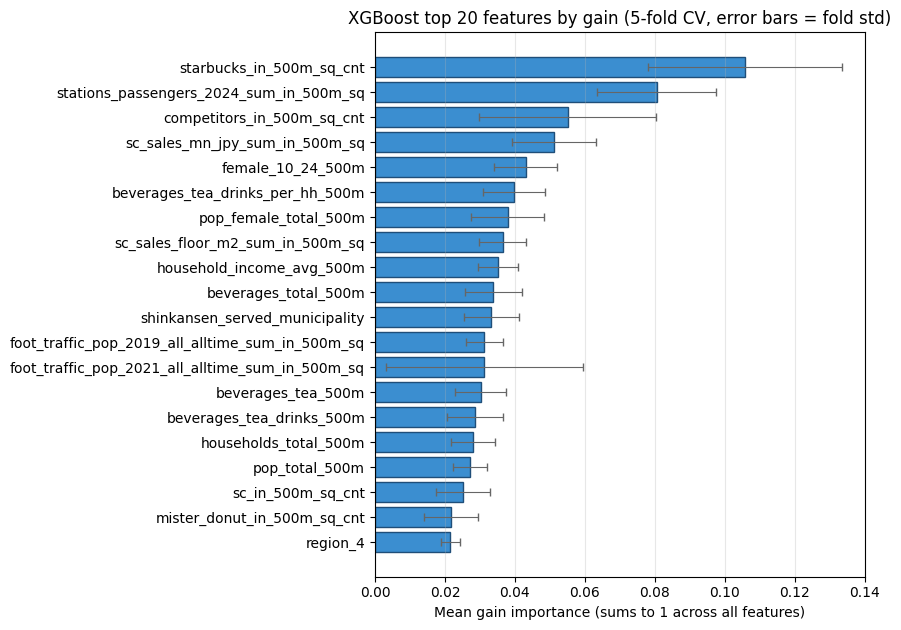

Chart -> c:\Users\52333\OneDrive - Bain\Desktop\CSE\T5HM\output\models\feature_importance_top20.png


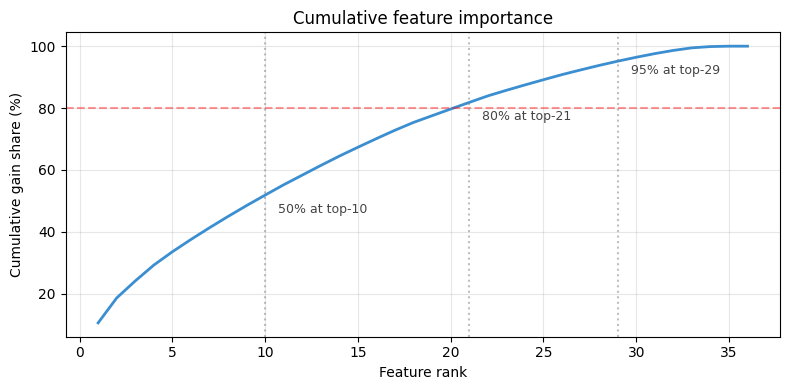

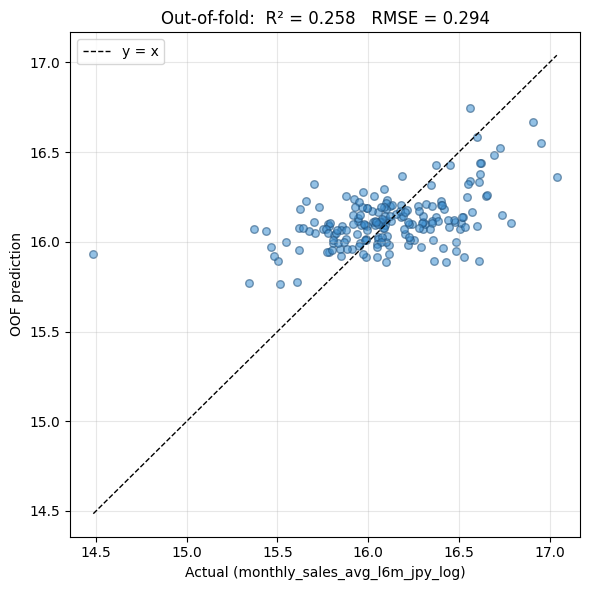

In [106]:
# 6a. Feature-importance ranking (averaged across folds).
import matplotlib.pyplot as plt

# XGBoost feature_importances_ is gain-normalized (sums to 1). Collect per fold + average.
imp_df = pd.DataFrame({f'fold_{j+1}': m.feature_importances_ for j, m in enumerate(models)},
                      index=X_train.columns)
fold_cols = [f'fold_{j+1}' for j in range(len(models))]
imp_df['mean']             = imp_df[fold_cols].mean(axis=1)
imp_df['std']              = imp_df[fold_cols].std(axis=1)
imp_df = imp_df.sort_values('mean', ascending=False)
imp_df['rank']             = range(1, len(imp_df) + 1)
imp_df['cumulative_share'] = imp_df['mean'].cumsum() / imp_df['mean'].sum()

# Save full ranking
imp_path = OUT_MODELS / 'feature_importance.csv'
imp_df.to_csv(imp_path, encoding='utf-8-sig')
print(f'Full ranking ({len(imp_df)} features) saved -> {imp_path}')

# Print top 20
TOP_N = 20
print(f'\nTop {TOP_N} features by mean gain importance:')
print(imp_df.head(TOP_N)[['rank', 'mean', 'std', 'cumulative_share']].round(4).to_string())

# 6b. Horizontal bar chart of top-N with fold-stability error bars.
top = imp_df.head(TOP_N).iloc[::-1]   # reverse so most-important is at top
fig, ax = plt.subplots(figsize=(9, max(4.5, 0.32 * TOP_N)))
ax.barh(top.index, top['mean'], xerr=top['std'],
        color='#3b8ed0', edgecolor='#1f4e79',
        error_kw={'ecolor': '#666', 'capsize': 3, 'elinewidth': 0.8})
ax.set_xlabel('Mean gain importance (sums to 1 across all features)')
ax.set_title(f'XGBoost top {TOP_N} features by gain (5-fold CV, error bars = fold std)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
png = OUT_MODELS / 'feature_importance_top20.png'
plt.savefig(png, dpi=120, bbox_inches='tight')
plt.show()
print(f'Chart -> {png}')

# 6c. Cumulative-importance curve.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(imp_df['rank'], imp_df['cumulative_share'] * 100, color='#3b8ed0', lw=2)
for thresh in [50, 80, 95]:
    n_needed = int((imp_df['cumulative_share'] * 100 <= thresh).sum()) + 1
    ax.axvline(n_needed, color='gray', ls=':', alpha=0.5)
    ax.text(n_needed + 0.5, thresh - 4, f' {thresh}% at top-{n_needed}',
            fontsize=9, color='#444')
ax.axhline(80, color='red', ls='--', alpha=0.4)
ax.set_xlabel('Feature rank')
ax.set_ylabel('Cumulative gain share (%)')
ax.set_title('Cumulative feature importance')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_MODELS / 'feature_importance_cumulative.png', dpi=120, bbox_inches='tight')
plt.show()

# 6d. OOF prediction vs actual scatter.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_train, oof, alpha=0.55, s=30, color='#3b8ed0', edgecolor='#1f4e79')
lo, hi = min(y_train.min(), oof.min()), max(y_train.max(), oof.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')
r2_  = r2_score(y_train, oof)
rmse_ = np.sqrt(mean_squared_error(y_train, oof))
ax.set_xlabel(f'Actual ({y.name})')
ax.set_ylabel('OOF prediction')
ax.set_title(f'Out-of-fold:  R² = {r2_:.3f}   RMSE = {rmse_:.3f}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_MODELS / 'oof_pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

# 6e. Optional SHAP (install with `pip install shap` then flip the flag).
RUN_SHAP = False
if RUN_SHAP:
    import shap
    explainer = shap.TreeExplainer(models[-1])
    shap_values = explainer.shap_values(X_train)
    shap.summary_plot(shap_values, X_train, max_display=20)

In [107]:
# (debug cell removed)
pass

SHAP ranking (36 features) saved -> c:\Users\52333\OneDrive - Bain\Desktop\CSE\T5HM\output\models\shap_importance.csv

Top 20 features by mean |SHAP|  (↑ = pushes sales UP when feature is high):
rank  feature                                                |SHAP|    signed  dir   ρ
   1  stations_passengers_2024_sum_in_500m_sq                0.0316   -0.0011  ↑↑  +0.71
   2  starbucks_in_500m_sq_cnt                               0.0306   -0.0039  ↑↑  +0.84
   3  household_income_avg_500m                              0.0265   +0.0008  ↑↑  +0.84
   4  sc_sales_mn_jpy_sum_in_500m_sq                         0.0257   +0.0001  ↑↑  +0.80
   5  beverages_tea_drinks_per_hh_500m                       0.0219   +0.0031  ↑↑  +0.78
   6  sc_sales_floor_m2_sum_in_500m_sq                       0.0193   +0.0008  ↑↑  +0.81
   7  competitors_in_500m_sq_cnt                             0.0131   -0.0001  ↑↑  +0.53
   8  female_10_24_500m                                      0.0127   +0.0004  ↓↓  -0.64
   9  

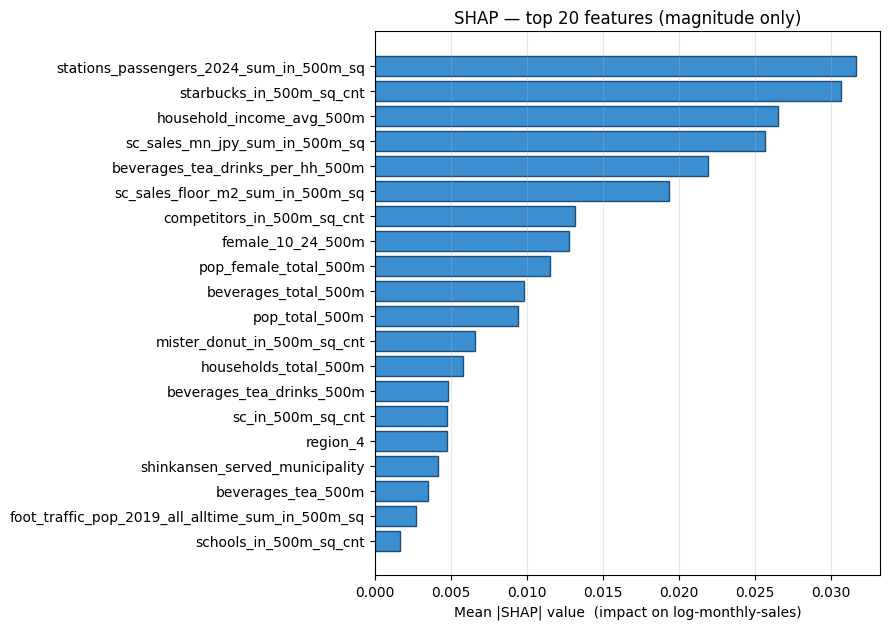

Bar chart -> c:\Users\52333\OneDrive - Bain\Desktop\CSE\T5HM\output\models\shap_bar.png


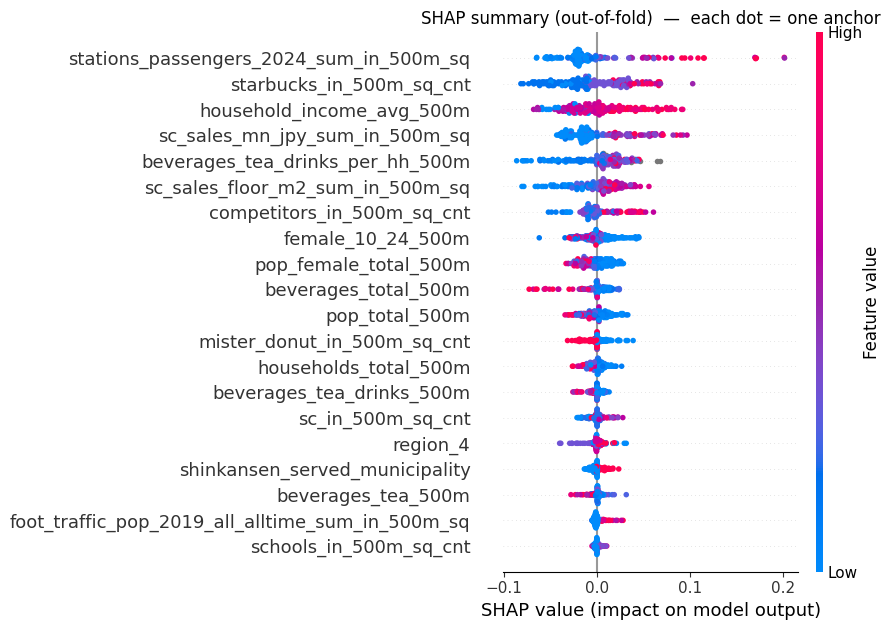

Beeswarm -> c:\Users\52333\OneDrive - Bain\Desktop\CSE\T5HM\output\models\shap_summary_beeswarm.png


In [108]:
# 6d. SHAP values — magnitude AND direction.
#
# Gain importance only says "the model uses this feature a lot". SHAP tells us
# WHICH WAY each feature pushes the prediction: positive SHAP → predicts higher
# sales when the feature is high; negative → predicts lower.
#
# We compute out-of-fold SHAP: for each fold, explain the validation rows with
# the model trained on the other 4 folds. Stacking all 5 OOF chunks gives one
# leakage-free SHAP value per anchor per feature.
import shap
from scipy.stats import spearmanr

oof_shap = np.full((len(X_train), X_train.shape[1]), np.nan)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for (tr_idx, va_idx), m in zip(kf.split(X_train), models):
    explainer = shap.TreeExplainer(m)
    oof_shap[va_idx] = explainer.shap_values(X_train.iloc[va_idx])

# ── Build the SHAP ranking table ─────────────────────────────────────
shap_df = pd.DataFrame({
    'feature'      : X_train.columns,
    'mean_abs_shap': np.abs(oof_shap).mean(axis=0),     # magnitude (always >= 0)
    'mean_shap'    : oof_shap.mean(axis=0),             # signed average effect
})

# Spearman corr between feature value and its SHAP -> robust direction signal
# (works for both monotonic numerics and ordinal categoricals; skips constants)
def _direction(col):
    vals = X_train[col]
    if pd.api.types.is_numeric_dtype(vals):
        v = pd.to_numeric(vals, errors='coerce').values
    elif isinstance(vals.dtype, pd.CategoricalDtype):
        v = vals.cat.codes.values.astype(float)
    else:
        return np.nan
    s = oof_shap[:, X_train.columns.get_loc(col)]
    mask = ~np.isnan(v) & ~np.isnan(s)
    if mask.sum() < 10 or np.unique(v[mask]).size < 3:
        return np.nan
    rho, _ = spearmanr(v[mask], s[mask])
    return rho

shap_df['spearman_dir'] = [_direction(c) for c in X_train.columns]
shap_df = shap_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_df.insert(0, 'rank', range(1, len(shap_df) + 1))
shap_df['cumulative_share'] = (shap_df['mean_abs_shap'].cumsum() /
                                shap_df['mean_abs_shap'].sum())

# Save
shap_path = OUT_MODELS / 'shap_importance.csv'
shap_df.to_csv(shap_path, index=False, encoding='utf-8-sig')
print(f'SHAP ranking ({len(shap_df)} features) saved -> {shap_path}')

# Print top 20 with direction arrows
def _arrow(rho):
    if pd.isna(rho): return '·'
    if rho >= 0.25:  return '↑↑'
    if rho >= 0.10:  return '↑ '
    if rho <= -0.25: return '↓↓'
    if rho <= -0.10: return '↓ '
    return '~ '

TOP_N = 20
print(f'\nTop {TOP_N} features by mean |SHAP|  (↑ = pushes sales UP when feature is high):')
print(f'{"rank":>4s}  {"feature":52s}  {"|SHAP|":>7s}  {"signed":>8s}  dir   ρ')
for _, r in shap_df.head(TOP_N).iterrows():
    rho = r['spearman_dir']
    rho_str = f'{rho:+.2f}' if not pd.isna(rho) else '  - '
    print(f'{r["rank"]:>4d}  {r["feature"]:52s}  {r["mean_abs_shap"]:>7.4f}  '
          f'{r["mean_shap"]:>+8.4f}  {_arrow(rho)}  {rho_str}')

# ── SHAP bar chart (sorted by mean |SHAP|) ───────────────────────────
top = shap_df.head(TOP_N).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, max(4.5, 0.32 * TOP_N)))
ax.barh(top['feature'], top['mean_abs_shap'], color='#3b8ed0', edgecolor='#1f4e79')
ax.set_xlabel('Mean |SHAP| value  (impact on log-monthly-sales)')
ax.set_title(f'SHAP — top {TOP_N} features (magnitude only)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_MODELS / 'shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Bar chart -> {OUT_MODELS / "shap_bar.png"}')

# ── SHAP beeswarm summary (best single chart for the deck) ───────────
# Each dot is one anchor; x = SHAP value (impact on prediction);
# color = feature value (high = red, low = blue). Shows distribution + direction.
plt.figure(figsize=(9, max(4.5, 0.32 * TOP_N)))
# shap.summary_plot needs numeric X for coloring; convert categoricals to codes
X_shap = X_train.copy()
for c in X_shap.select_dtypes(['category']).columns:
    X_shap[c] = X_shap[c].cat.codes
shap.summary_plot(oof_shap, X_shap, max_display=TOP_N, show=False,
                  plot_size=(9, max(4.5, 0.32 * TOP_N)))
plt.title('SHAP summary (out-of-fold)  —  each dot = one anchor')
plt.tight_layout()
plt.savefig(OUT_MODELS / 'shap_summary_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Beeswarm -> {OUT_MODELS / "shap_summary_beeswarm.png"}')

## 7. Model comparison — XGBoost vs Random Forest vs Linear vs Lasso

We've been using XGBoost. To make sure we picked the right tool, compare against three baselines on the **same OOF protocol** (5 seeds × 5-fold KFold = 25 OOF preds per anchor):

| Model | Why include |
|---|---|
| **XGBoost** | Gradient-boosted trees — current champion |
| **Random Forest** | Bagged trees — different bias/variance trade-off; good sanity check |
| **Linear Regression** | Sanity baseline — if XGBoost can't beat OLS, the non-linearities aren't real |
| **Lasso Regression** | L1-regularized linear — feature-sparse baseline; helpful when n is small |

Linear models need preprocessing (median impute for NaN, one-hot for categoricals, standardize). XGBoost / RF use raw data.

This cell only reports R² / RMSE / MAE — the winner is then used in Section 8 for detailed segmented evaluation.

In [109]:
# 7. Model comparison.
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identify column types for preprocessing
cat_cols_cmp = X_train.select_dtypes(include=['category', 'object']).columns.tolist()
num_cols_cmp = [c for c in X_train.columns if c not in cat_cols_cmp]

# Linear-model preprocessing: median-impute numerics, OHE categoricals, then scale.
linear_pre = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale',  StandardScaler())]), num_cols_cmp),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('ohe',    OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False))]), cat_cols_cmp),
])

# Tree-model preprocessing for Random Forest: just impute NaN (RF can't handle natively;
# unlike XGBoost). Keep categoricals as numeric codes.
def _rf_prepare(df):
    df = df.copy()
    for c in cat_cols_cmp:
        df[c] = df[c].astype('category').cat.codes.replace(-1, np.nan)
    return df

rf_imputer = SimpleImputer(strategy='median')

MODELS = {
    'XGBoost'           : ('native',   xgb.XGBRegressor(**XGB_PARAMS)),
    'Random Forest'     : ('rf',       RandomForestRegressor(
                                            n_estimators=500, max_depth=8,
                                            min_samples_leaf=3, n_jobs=-1,
                                            random_state=42)),
    'Linear Regression' : ('linear',   LinearRegression()),
    'Lasso Regression'  : ('linear',   LassoCV(cv=5, max_iter=10000, random_state=42)),
}

def cv_model(name, mode, mdl, X_, y_, seeds=SEEDS, n_splits=5):
    """Repeated K-fold CV. Returns dict with OOF preds + metrics."""
    mask = y_.notna()
    Xt, yt = X_[mask].reset_index(drop=True), y_[mask].reset_index(drop=True)
    oof_seeds = []
    for s in seeds:
        oof = np.full(len(Xt), np.nan)
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=s)
        for tr, va in kf.split(Xt):
            X_tr, X_va = Xt.iloc[tr], Xt.iloc[va]
            y_tr, y_va = yt.iloc[tr], yt.iloc[va]
            if mode == 'native':
                m = xgb.XGBRegressor(**{**XGB_PARAMS, 'random_state': s})
                m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
                pred = m.predict(X_va)
            elif mode == 'rf':
                X_tr_p = _rf_prepare(X_tr); X_va_p = _rf_prepare(X_va)
                X_tr_p = pd.DataFrame(rf_imputer.fit_transform(X_tr_p), columns=X_tr_p.columns)
                X_va_p = pd.DataFrame(rf_imputer.transform(X_va_p),     columns=X_va_p.columns)
                m = RandomForestRegressor(**{**mdl.get_params(), 'random_state': s})
                m.fit(X_tr_p, y_tr)
                pred = m.predict(X_va_p)
            else:  # linear / lasso
                pipe = Pipeline([('pre', linear_pre), ('mdl', mdl)])
                pipe.fit(X_tr, y_tr)
                pred = pipe.predict(X_va)
            oof[va] = pred
        oof_seeds.append(oof)
    oof_avg = np.mean(oof_seeds, axis=0)
    return dict(name=name, oof=oof_avg, y=yt,
                rmse=float(np.sqrt(mean_squared_error(yt, oof_avg))),
                mae=float(mean_absolute_error(yt, oof_avg)),
                r2=float(r2_score(yt, oof_avg)))

print('Comparing 4 models on current target  (seeds × folds = '
      f'{len(SEEDS)} × 5  =  {len(SEEDS) * 5} OOF preds per anchor)')
print(f'{"Model":20s}  {"RMSE":>6s} {"MAE":>6s} {"R^2":>7s}')
cmp_results = {}
for name, (mode, mdl) in MODELS.items():
    r = cv_model(name, mode, mdl, X_train, y_train)
    cmp_results[name] = r
    print(f'{name:20s}  {r["rmse"]:>6.3f} {r["mae"]:>6.3f} {r["r2"]:>7.3f}')

cmp_df = pd.DataFrame([
    {'model': name, 'rmse': r['rmse'], 'mae': r['mae'], 'r2': r['r2']}
    for name, r in cmp_results.items()
]).sort_values('r2', ascending=False).reset_index(drop=True)

best_model_name = cmp_df.iloc[0]['model']
print(f'\nWinner: {best_model_name}  (R^2 = {cmp_df.iloc[0]["r2"]:.3f})')
cmp_df.to_csv(OUT_MODELS / 'model_comparison.csv', index=False, encoding='utf-8-sig')
print(f'-> {OUT_MODELS / "model_comparison.csv"}')

Comparing 4 models on current target  (seeds × folds = 5 × 5  =  25 OOF preds per anchor)
Model                   RMSE    MAE     R^2
XGBoost                0.288  0.222   0.290
Random Forest          0.292  0.223   0.270
Linear Regression      0.376  0.276  -0.208
Lasso Regression       0.306  0.237   0.197

Winner: XGBoost  (R^2 = 0.290)
-> c:\Users\52333\OneDrive - Bain\Desktop\CSE\T5HM\output\models\model_comparison.csv


## 8. Detailed evaluation — train vs test R² by segment

For the winning model from Section 7, we report:

- **Training R²**: predictions on the rows it was trained on (after refit on full data) — diagnostic of how much the model can memorize. *Always optimistic*, included only for the train/test gap (overfit indicator).
- **Test R² (OOF)**: from the repeated K-fold setup in Section 7 — this is the honest, deployable read.

Each metric is computed **overall** plus split by:

- **Store type**: SC (`is_inside_sc == 1`) vs non-SC
- **Region (`region_4`)**:
    - Tokyo
    - Osaka
    - Other focus cities (Nagoya / Fukuoka / Sapporo)
    - Other regions

> **Small-sample caveat**: segments with < 10 anchors have noisy R² and are flagged `⚠ small n`. We intentionally use aggregated `region_4` only (no prefecture-level finer categories).

In [110]:
# 8. Segmented evaluation for the winning model.
# Build segmentation aligned to the same training rows.
mask_train = y.notna()
seg = pd.DataFrame({
    'anchor_id'  : anchor_index.loc[mask_train, 'anchor_id'].values,
    'region_4'   : X.loc[mask_train, 'region_4'].astype(str).str.strip().values
                   if 'region_4' in X.columns else 'Other regions',
    'is_inside_sc': X.loc[mask_train, 'is_inside_sc'].values
                    if 'is_inside_sc' in X.columns else 0,
}).reset_index(drop=True)
seg['store_type'] = np.where(seg['is_inside_sc'] == 1, 'SC', 'Non-SC')

# Refit the winning model on FULL data for training R²
best_info = cmp_results[best_model_name]
y_test_oof = best_info['oof']
y_train_actual = best_info['y'].values

mode, mdl_proto = MODELS[best_model_name]
if mode == 'native':
    # Refit on full data: cannot use early stopping without eval set, so strip it.
    refit_params = {k: v for k, v in XGB_PARAMS.items() if k != 'early_stopping_rounds'}
    m_full = xgb.XGBRegressor(**refit_params)
    m_full.fit(X_train, y_train, verbose=False)
    y_train_pred = m_full.predict(X_train)
elif mode == 'rf':
    X_train_p = _rf_prepare(X_train)
    X_train_p = pd.DataFrame(rf_imputer.fit_transform(X_train_p), columns=X_train_p.columns)
    m_full = RandomForestRegressor(**mdl_proto.get_params())
    m_full.fit(X_train_p, y_train)
    y_train_pred = m_full.predict(X_train_p)
else:
    pipe = Pipeline([('pre', linear_pre), ('mdl', mdl_proto)])
    pipe.fit(X_train, y_train)
    y_train_pred = pipe.predict(X_train)

def segment_r2(actual, pred, mask, label):
    """Returns (n, r2) for a segment; flags small samples."""
    n = int(mask.sum())
    if n < 2:
        return n, np.nan, '⚠ n<2'
    r2 = r2_score(actual[mask], pred[mask])
    flag = '⚠ small n' if n < 10 else ''
    return n, r2, flag

# Build evaluation table
def build_eval(actual, pred, label_dataset):
    rows = []
    rows.append({'dataset': label_dataset, 'segment': 'Overall', 'group': 'all',
                 'n': len(actual), 'r2': r2_score(actual, pred), 'rmse':
                 np.sqrt(mean_squared_error(actual, pred)),
                 'mae': mean_absolute_error(actual, pred), 'flag': ''})
    # By store type
    for grp in ['SC', 'Non-SC']:
        mask = (seg['store_type'] == grp).values
        n, r2, flag = segment_r2(actual, pred, mask, grp)
        rmse = float(np.sqrt(mean_squared_error(actual[mask], pred[mask]))) if n >= 2 else np.nan
        mae  = float(mean_absolute_error(actual[mask], pred[mask])) if n >= 2 else np.nan
        rows.append({'dataset': label_dataset, 'segment': 'Store type', 'group': grp,
                     'n': n, 'r2': r2, 'rmse': rmse, 'mae': mae, 'flag': flag})
    # By region_4 (aggregated only)
    for grp in ['Tokyo', 'Osaka', 'Other focus cities', 'Other regions']:
        mask = (seg['region_4'] == grp).values
        n, r2, flag = segment_r2(actual, pred, mask, grp)
        rmse = float(np.sqrt(mean_squared_error(actual[mask], pred[mask]))) if n >= 2 else np.nan
        mae  = float(mean_absolute_error(actual[mask], pred[mask])) if n >= 2 else np.nan
        rows.append({'dataset': label_dataset, 'segment': 'Region', 'group': grp,
                     'n': n, 'r2': r2, 'rmse': rmse, 'mae': mae, 'flag': flag})
    return pd.DataFrame(rows)

eval_train = build_eval(y_train_actual, y_train_pred, 'Train')
eval_test  = build_eval(y_train_actual, y_test_oof,    'Test (OOF)')
eval_df = pd.concat([eval_train, eval_test], ignore_index=True)

print(f'=== {best_model_name}  —  R² breakdown ===\n')
for ds in ['Train', 'Test (OOF)']:
    print(f'--- {ds} ---')
    sub = eval_df[eval_df['dataset'] == ds]
    print(f'{"segment":12s} {"group":10s} {"n":>4s}  {"R^2":>7s}  {"RMSE":>6s}  {"MAE":>6s}  flag')
    for _, r in sub.iterrows():
        r2_str = f'{r["r2"]:>7.3f}' if not pd.isna(r['r2']) else '     -'
        rm_str = f'{r["rmse"]:>6.3f}' if not pd.isna(r['rmse']) else '    -'
        ma_str = f'{r["mae"]:>6.3f}' if not pd.isna(r['mae']) else '    -'
        print(f'{r["segment"]:12s} {r["group"]:10s} {r["n"]:>4d}  {r2_str}  {rm_str}  {ma_str}  {r["flag"]}')
    print()

# Extra view requested: inside-SC-only model performance (OOF)
inside_mask = (seg['store_type'] == 'SC').values
if inside_mask.sum() >= 30:
    X_in = X_train.loc[inside_mask].reset_index(drop=True)
    y_in = y_train.loc[inside_mask].reset_index(drop=True)
    r_in = cv_model(best_model_name, mode, mdl_proto, X_in, y_in)
    print('Inside-SC-only model (OOF):')
    print(f'  n={inside_mask.sum()}  RMSE={r_in["rmse"]:.3f}  MAE={r_in["mae"]:.3f}  R^2={r_in["r2"]:.3f}')

eval_df.to_csv(OUT_MODELS / 'eval_by_segment.csv', index=False, encoding='utf-8-sig')
print(f'-> {OUT_MODELS / "eval_by_segment.csv"}')

=== XGBoost  —  R² breakdown ===

--- Train ---
segment      group         n      R^2    RMSE     MAE  flag
Overall      all         186    0.981   0.047   0.030  
Store type   SC          176    0.979   0.048   0.030  
Store type   Non-SC       10    0.996   0.026   0.024  
Region       Tokyo        42    0.995   0.024   0.019  
Region       Osaka        18    0.995   0.028   0.021  
Region       Other focus cities   29    0.987   0.033   0.027  
Region       Other regions   97    0.970   0.060   0.037  

--- Test (OOF) ---
segment      group         n      R^2    RMSE     MAE  flag
Overall      all         186    0.290   0.288   0.222  
Store type   SC          176    0.260   0.286   0.220  
Store type   Non-SC       10    0.465   0.318   0.265  
Region       Tokyo        42    0.342   0.266   0.213  
Region       Osaka        18    0.447   0.295   0.221  
Region       Other focus cities   29    0.006   0.284   0.235  
Region       Other regions   97    0.245   0.297   0.223  

Insid

## 9. Alternative target — sales per m² (productivity)

The default target is **monthly sales (JPY)** — total throughput. A second view is **sales per m²** (JPY / month / m²) — store productivity, controlling for footprint.

- **Target**: `monthly_sales_avg_l6m_jpy / store_area_m2` (log-transformed)
- **Feature change**: drop `store_area_m2` from X (otherwise the target leaks into the features)
- **Same 4-model comparison** as Section 7

This is useful because some Gongcha sites are big SCs (high sales / low productivity) while some are small street-front shops (lower sales / high productivity). If `sales / m²` is easier to predict than total sales, then catchment features map to productivity more cleanly than to absolute volume.

In [111]:
# 9. Sales per m² as the target — quick comparison across 4 models + 2 alt targets.
#
# We loop over three target definitions: (a) current default L6M JPY, (b) alltime
# JPY, (c) sales per m² (L6M). For (c), drop store_area_m2 from X because it's
# the denominator -- keeping it would be leakage.

ALT_TARGETS = {
    'monthly_sales_avg_l6m_jpy'        : {'drop_area': False, 'label': 'L6M sales (JPY)'},
    'monthly_sales_avg_alltime_jpy'    : {'drop_area': False, 'label': 'Alltime sales (JPY)'},
    'sales_per_sqm_l6m_jpy'            : {'drop_area': True,  'label': 'L6M sales / m² (JPY)'},
    'ebitda_2025_local'                : {'drop_area': False, 'label': 'EBITDA 2025 (local)'},
    'ebitda_margin_2025'               : {'drop_area': False, 'label': 'EBITDA margin 2025'},
}

# Build sales-per-sqm column by joining store_area_m2 from the master features file
y_long = pd.read_csv(OUT_TABLES / 'y_targets.csv')
y_long = y_long.merge(mf[['anchor_id', 'store_area_m2']], on='anchor_id', how='left')
y_long['sales_per_sqm_l6m_jpy'] = (y_long['monthly_sales_avg_l6m_jpy'] /
                                   y_long['store_area_m2'])
y_long.loc[y_long['store_area_m2'].isna() | (y_long['store_area_m2'] <= 0),
           'sales_per_sqm_l6m_jpy'] = np.nan

target_compare_rows = []
for tcol, spec in ALT_TARGETS.items():
    if tcol not in y_long.columns:
        print(f'(skip {tcol} — not in y_targets.csv)')
        continue
    yd = anchor_index.merge(y_long[['anchor_id', tcol]], on='anchor_id', how='left')
    yt_raw = yd[tcol]
    yt = np.log1p(yt_raw) if LOG_TARGET else yt_raw
    n_valid = int(yt.notna().sum())

    # Feature set for this target (drop area if leakage)
    feats = [c for c in X.columns if not (spec['drop_area'] and c == 'store_area_m2')]
    X_alt = X[feats]

    print(f'\n--- {spec["label"]}  ({tcol})  n={n_valid}/186 valid ---')
    print(f'  {"Model":20s}  {"RMSE":>6s} {"MAE":>6s} {"R^2":>7s}')
    for name, (mode, mdl) in MODELS.items():
        cat_a = X_alt.select_dtypes(include=['category', 'object']).columns.tolist()
        num_a = [c for c in X_alt.columns if c not in cat_a]
        linear_pre = ColumnTransformer([
            ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                              ('scale',  StandardScaler())]), num_a),
            ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                              ('ohe',    OneHotEncoder(handle_unknown='ignore',
                                                       sparse_output=False))]), cat_a),
        ])
        cat_cols_cmp, num_cols_cmp = cat_a, num_a
        r = cv_model(name, mode, mdl, X_alt, yt)
        target_compare_rows.append({
            'target': spec['label'], 'target_col': tcol, 'n_valid': n_valid,
            'model': name, 'rmse': r['rmse'], 'mae': r['mae'], 'r2': r['r2'],
        })
        print(f'  {name:20s}  {r["rmse"]:>6.3f} {r["mae"]:>6.3f} {r["r2"]:>7.3f}')

target_compare_df = pd.DataFrame(target_compare_rows)
target_compare_df.to_csv(OUT_MODELS / 'target_x_model_comparison.csv',
                         index=False, encoding='utf-8-sig')

# Best (model, target) pair
best_pair = target_compare_df.sort_values('r2', ascending=False).iloc[0]
print(f'\n=== BEST (target × model) ===')
print(f'  target : {best_pair["target"]}')
print(f'  model  : {best_pair["model"]}')
print(f'  R^2    : {best_pair["r2"]:.3f}')
print(f'  RMSE   : {best_pair["rmse"]:.3f}')
print(f'-> {OUT_MODELS / "target_x_model_comparison.csv"}')


--- L6M sales (JPY)  (monthly_sales_avg_l6m_jpy)  n=186/186 valid ---
  Model                   RMSE    MAE     R^2
  XGBoost                0.288  0.222   0.290
  Random Forest          0.292  0.223   0.270
  Linear Regression      0.376  0.276  -0.208
  Lasso Regression       0.306  0.237   0.197

--- Alltime sales (JPY)  (monthly_sales_avg_alltime_jpy)  n=186/186 valid ---
  Model                   RMSE    MAE     R^2
  XGBoost                0.286  0.223   0.188
  Random Forest          0.291  0.229   0.163
  Linear Regression      0.359  0.279  -0.276
  Lasso Regression       0.303  0.236   0.091

--- L6M sales / m² (JPY)  (sales_per_sqm_l6m_jpy)  n=184/186 valid ---
  Model                   RMSE    MAE     R^2
  XGBoost                0.545  0.428   0.127
  Random Forest          0.562  0.446   0.071
  Linear Regression      0.666  0.528  -0.305
  Lasso Regression       0.573  0.447   0.034

--- EBITDA 2025 (local)  (ebitda_2025_local)  n=149/186 valid ---
  Model              

## 10. Export results → Excel workbook

Roll everything into a single `.xlsx` so the team can review without re-running the notebook. Sheets:

1. `summary`        — headline numbers, picked target/model, dataset size
2. `model_comparison` — Section 7 4-model R²/RMSE/MAE
3. `target_x_model` — Section 9 cross-tab of (target × model)
4. `eval_by_segment` — Section 8 train/test R² split by store type & region
5. `hyperparam_sweep` — Section 5 XGBoost config sweep
6. `feature_importance` — Section 6a XGBoost gain ranking
7. `shap_importance` — Section 6d SHAP ranking with direction
8. `feature_catalog` — Section 2 catalog (which features kept/dropped + why)

The file lives at `output/models/T5HM_modeling_results.xlsx`.

In [112]:
# 10. Write a multi-sheet Excel workbook with everything.
xlsx_path = OUT_MODELS / 'T5HM_modeling_results.xlsx'

# Build summary sheet
summary_rows = [
    ('Project',          'T5HM — Gongcha Japan whitespace'),
    ('Notebook',         '04_modeling.ipynb'),
    ('Run timestamp',    pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')),
    ('Target (default)', TARGET_COL),
    ('Log-transformed',  LOG_TARGET),
    ('Feature scope',    'Strict 500m catchment + planned-design + admin'),
    ('# anchors',        int(len(X))),
    ('# train rows',     int(len(X_train))),
    ('# features',       int(X.shape[1])),
    ('Best model',       best_model_name),
    ('Best R^2 (OOF)',   round(float(cmp_df.iloc[0]['r2']), 4)),
    ('Best RMSE',        round(float(cmp_df.iloc[0]['rmse']), 4)),
    ('Best MAE',         round(float(cmp_df.iloc[0]['mae']), 4)),
    ('Best (target × model)', f'{best_pair["target"]}  /  {best_pair["model"]}'),
    ('Best cross R^2',   round(float(best_pair['r2']), 4)),
]
summary_df = pd.DataFrame(summary_rows, columns=['key', 'value'])

# Hyperparam sweep table (collected during Section 5)
sweep_rows = []
for name, (params, r) in results.items():
    sweep_rows.append({'config': name, **params, 'rmse': r['rmse'],
                       'mae': r['mae'], 'r2': r['r2']})
sweep_df = pd.DataFrame(sweep_rows).sort_values('r2', ascending=False)

# Catalog export (compatible with both old/new CATALOG schemas)
# old cols: dtype_hint / description / word_doc_metric
# new cols: role       / doc         / attr_ref
_dtype_col = 'dtype_hint' if 'dtype_hint' in CATALOG.columns else ('role' if 'role' in CATALOG.columns else None)
_desc_col  = 'description' if 'description' in CATALOG.columns else ('doc' if 'doc' in CATALOG.columns else None)
_ref_col   = 'word_doc_metric' if 'word_doc_metric' in CATALOG.columns else ('attr_ref' if 'attr_ref' in CATALOG.columns else None)

base_cols = ['col', 'family', 'keep']
opt_cols = [c for c in [_dtype_col, _desc_col, _ref_col] if c is not None]
catalog_export = CATALOG[base_cols + opt_cols].copy()

rename_map = {
    'col': 'feature',
    'keep': 'used_in_model',
}
if _dtype_col is not None:
    rename_map[_dtype_col] = 'dtype'
if _desc_col is not None:
    rename_map[_desc_col] = 'description'
if _ref_col is not None:
    rename_map[_ref_col] = 'word_doc_metric'

catalog_export = catalog_export.rename(columns=rename_map)

# Ensure a stable output schema even if source columns are missing.
for c in ['dtype', 'description', 'word_doc_metric']:
    if c not in catalog_export.columns:
        catalog_export[c] = pd.NA

catalog_export = catalog_export[['feature', 'family', 'dtype', 'used_in_model',
                                 'description', 'word_doc_metric']]

def _write_book(path):
    with pd.ExcelWriter(path, engine='openpyxl') as xw:
        summary_df.to_excel(xw,         sheet_name='summary',           index=False)
        cmp_df.to_excel(xw,             sheet_name='model_comparison',  index=False)
        target_compare_df.to_excel(xw,  sheet_name='target_x_model',    index=False)
        eval_df.to_excel(xw,            sheet_name='eval_by_segment',   index=False)
        sweep_df.to_excel(xw,           sheet_name='hyperparam_sweep',  index=False)
        imp_df.reset_index().rename(columns={'index': 'feature'}) \
            .to_excel(xw,               sheet_name='feature_importance', index=False)
        shap_df.to_excel(xw,            sheet_name='shap_importance',    index=False)
        catalog_export.to_excel(xw,     sheet_name='feature_catalog',    index=False)

try:
    _write_book(xlsx_path)
except PermissionError:
    fallback = OUT_MODELS / f'T5HM_modeling_results_{pd.Timestamp.now():%Y%m%d_%H%M%S}.xlsx'
    _write_book(fallback)
    xlsx_path = fallback
    print('Note: default workbook was open/locked, wrote fallback file instead.')

print(f'Wrote {xlsx_path}')
print('Sheets: summary, model_comparison, target_x_model, eval_by_segment,')
print('        hyperparam_sweep, feature_importance, shap_importance, feature_catalog')

Note: default workbook was open/locked, wrote fallback file instead.
Wrote c:\Users\52333\OneDrive - Bain\Desktop\CSE\T5HM\output\models\T5HM_modeling_results_20260521_232023.xlsx
Sheets: summary, model_comparison, target_x_model, eval_by_segment,
        hyperparam_sweep, feature_importance, shap_importance, feature_catalog


## 11. Whitespace scoring

Use the saved model bundle from Section 5b to score candidate feature tables generated by `03_data_prep.ipynb`.

Candidate universes now supported in `03`:

- `ANCHOR_MODE = 'whitespace_grid'` → `output/tables/model_features_whitespace_grid_full.csv`
  - 500m x 500m grid over Japan (or selected prefectures if configured)
  - candidate center is excluded if it falls inside any existing Gongcha 500m x 500m store square
- `ANCHOR_MODE = 'whitespace_sc'` → `output/tables/model_features_whitespace_sc_full.csv`
  - one candidate per unopened shopping center
  - also excludes any SC center falling inside an existing Gongcha 500m x 500m store square
- `'whitespace_terminal'` → `output/tables/model_features_whitespace_terminal_full.csv`
  - one candidate per Terminal-station polygon (~2.5k anchors), produced by `src/build_terminal_features.py`

This scoring cell does **not** retrain the model and does **not** overwrite training files (`X_train.pkl`, `model_features_full.csv`). It writes separate candidate X and score files.

In [ ]:
# 11. Score whitespace candidate feature tables.
# Run after 03_data_prep has produced one or both candidate feature tables.
import joblib

MODEL_BUNDLE_PATH = OUT_MODELS / 'xgb_l6m_sales_model_bundle.pkl'
CANDIDATE_TABLES = {
    'whitespace_grid':     OUT_TABLES / 'model_features_whitespace_grid_full.csv',
    'whitespace_sc':       OUT_TABLES / 'model_features_whitespace_sc_full.csv',
    'whitespace_terminal': OUT_TABLES / 'model_features_whitespace_terminal_full.csv',
}


def prepare_candidate_X(candidate_features, bundle):
    """Derive deployment features, align to training feature schema, and cast categoricals."""
    cand_eng = derive_features(candidate_features)
    feature_cols = bundle['feature_cols']
    missing = [c for c in feature_cols if c not in cand_eng.columns]
    if missing:
        raise ValueError(f'Candidate feature table missing required model columns: {missing}')
    X_cand = cand_eng[feature_cols].copy()
    for c in bundle.get('categorical_cols', []):
        if c in X_cand.columns:
            X_cand[c] = X_cand[c].astype('category')
    return X_cand, cand_eng


def score_candidate_table(candidate_key, input_path, bundle_path=MODEL_BUNDLE_PATH):
    if not input_path.exists():
        print(f'Skip {candidate_key}: no file at {input_path}')
        return None

    bundle = joblib.load(bundle_path)
    candidate_features = pd.read_csv(input_path, encoding='utf-8-sig')
    X_cand, cand_eng = prepare_candidate_X(candidate_features, bundle)

    preds_log = np.column_stack([m.predict(X_cand) for m in bundle['models']])
    pred_mean_log = preds_log.mean(axis=1)
    pred_std_log = preds_log.std(axis=1)
    if bundle.get('log_target', False):
        pred_sales = np.expm1(pred_mean_log)
    else:
        pred_sales = pred_mean_log

    meta_cols = [c for c in [
        'anchor_id', 'anchor_source', 'anchor_name', 'address', 'lat', 'lng',
        'prefecture_en', 'is_inside_sc', 'candidate_sc_id',
        'candidate_sc_sales_floor_m2', 'candidate_sc_sales_mn_jpy'
    ] if c in cand_eng.columns]
    scores = cand_eng[meta_cols].copy()
    scores['pred_monthly_sales_jpy'] = pred_sales
    scores['pred_log_mean'] = pred_mean_log
    scores['pred_log_std_across_folds'] = pred_std_log
    scores['score_rank'] = scores['pred_monthly_sales_jpy'].rank(ascending=False, method='first').astype(int)
    scores = scores.sort_values('score_rank').reset_index(drop=True)

    x_path = OUT_MODELS / f'X_{candidate_key}.pkl'
    score_path = OUT_MODELS / f'{candidate_key}_scores.csv'
    X_cand.to_pickle(x_path)
    scores.to_csv(score_path, index=False, encoding='utf-8-sig')
    print(f'Scored {candidate_key}: {len(scores):,} candidates')
    print(f'  X      -> {x_path}')
    print(f'  scores -> {score_path}')
    return scores


if not MODEL_BUNDLE_PATH.exists():
    raise FileNotFoundError(f'Model bundle missing: {MODEL_BUNDLE_PATH}. Run Section 5b first.')

whitespace_scores = {}
for key, path in CANDIDATE_TABLES.items():
    res = score_candidate_table(key, path)
    if res is not None:
        whitespace_scores[key] = res

if whitespace_scores:
    for key, df in whitespace_scores.items():
        print(f'\nTop 10: {key}')
        display(df.head(10))
else:
    print('No whitespace candidate tables found yet. Run 03 with ANCHOR_MODE="whitespace_grid" and/or "whitespace_sc" first.')